# NASDAQ Stock Data Collection and KPI Analysis
# Author: Katsiaryna Chaikova
# Description: This script collects historical stock data from Yahoo Finance API, processes it, and performs data quality analysis based on key KPIs (completeness, latency, accuracy, and consistency).

In [1]:
!pip install yfinance

In [2]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
companies = {
    "META": {"company": "Meta", "start": "2025-03-01", "end": "2026-03-01"},
    "AMD": {"company": "AMD", "start": "2025-05-01", "end": "2026-04-01"},
    "NFLX": {"company": "Netflix", "start": "2025-07-01", "end": "2026-04-01"},
    "INTC": {"company": "Intel", "start": "2025-09-01", "end": "2026-04-01"},
    "ADBE": {"company": "Adobe", "start": "2025-11-01", "end": "2026-04-01"}
}

In [4]:
all_data = []

for ticker, dates in companies.items():
    data = yf.download(ticker, start=dates["start"], end=dates["end"], auto_adjust=False)
    data = data.reset_index()

    if isinstance(data.columns, pd.MultiIndex):
        data.columns = [col[0] for col in data.columns]

    data["Ticker"] = ticker
    data["Company"] = dates["company"] 
    data = data[["Date", "Ticker", "Company", "Close"]]

    data.to_csv(f"{ticker}.csv", index=False)
    all_data.append(data)

df = pd.concat(all_data, ignore_index=True)
df.to_csv("ALL_DATA.csv", index=False)

print("done")

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

done


In [5]:
df.head()

,Date,Ticker,Company,Close
0,2025-03-03,META,Meta,655.049988
1,2025-03-04,META,Meta,640.000000
2,2025-03-05,META,Meta,656.469971
3,2025-03-06,META,Meta,627.929993
4,2025-03-07,META,Meta,625.659973


In [6]:
df.to_csv("nasdaq_stock_data.csv", index=False)

## Descriptive statistics

In [7]:
for ticker, info in companies.items():
    company_name = info["company"]
    
    print(f"\n--- {company_name} ({ticker}) ---")
    print(df[df['Company'] == company_name][['Close']].describe())


--- Meta (META) ---
            Close
count  250.000000
mean   668.148520
std     67.551695
min    484.660004
25%    627.140015
50%    662.410004
75%    718.845001
max    790.000000

--- AMD (AMD) ---
            Close
count  230.000000
mean   184.965261
std     43.730459
min     96.650002
25%    157.097500
50%    196.590004
75%    215.887497
max    264.329987

--- Netflix (NFLX) ---
            Close
count  189.000000
mean   106.276344
std     15.595758
min     75.860001
25%     93.430000
50%    109.846001
75%    120.778000
max    129.718002

--- Intel (INTC) ---
            Close
count  146.000000
mean    39.686781
std      6.794247
min     24.000000
25%     36.354999
50%     39.525000
75%     45.407499
max     54.320000

--- Adobe (ADBE) ---
            Close
count  102.000000
mean   301.202157
std     37.963443
min    234.839996
25%    264.145004
50%    304.264999
75%    333.862511
max    357.529999


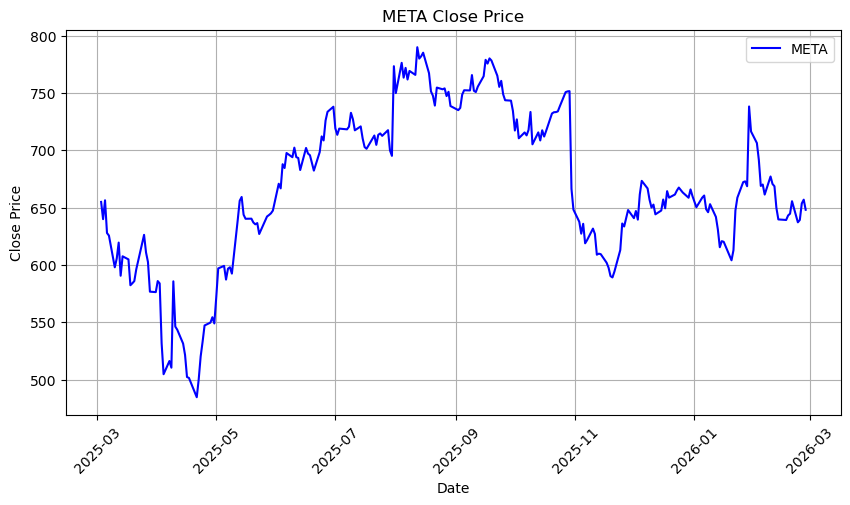

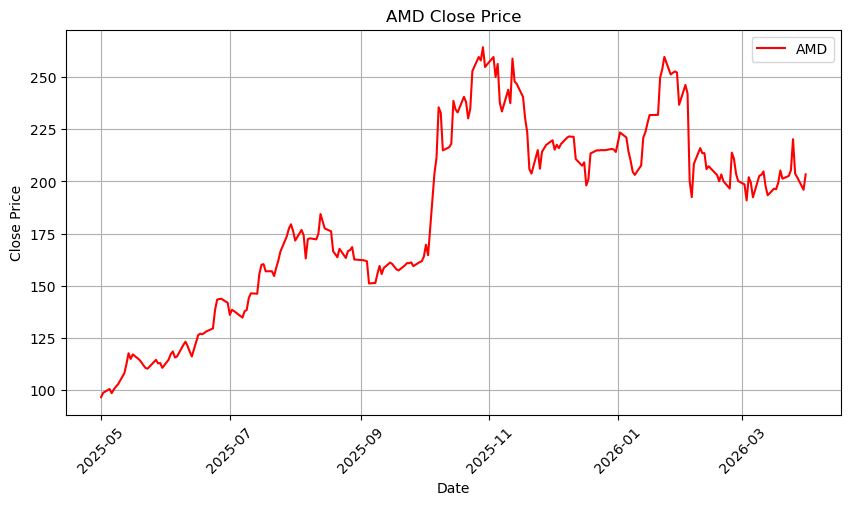

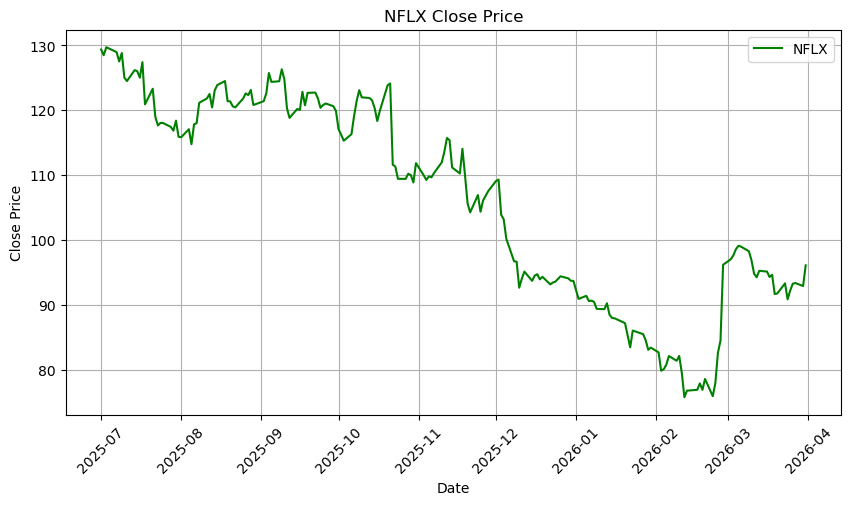

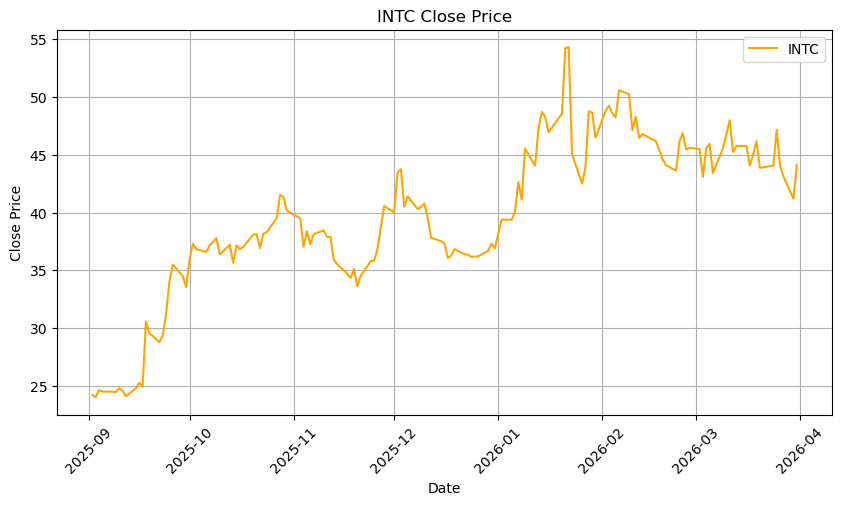

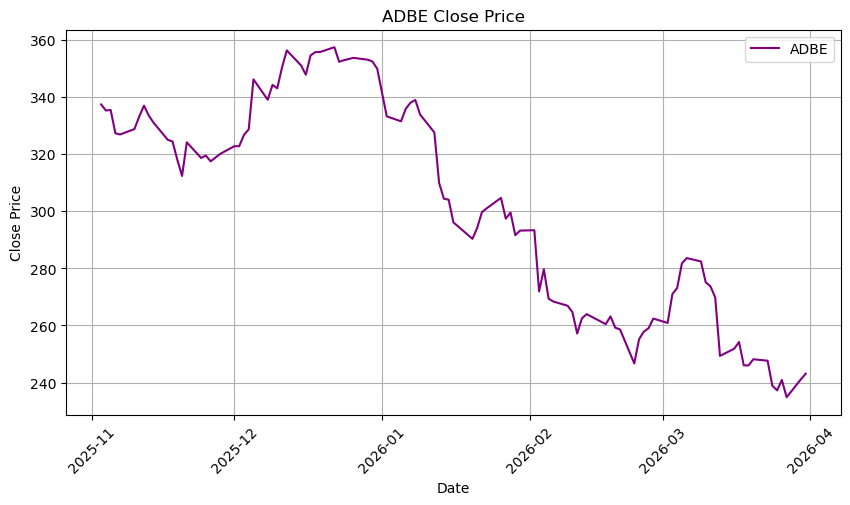

In [8]:
colors = ["blue", "red", "green", "orange", "purple"]

for i, ticker in enumerate(df["Ticker"].unique()):
    company_data = df[df["Ticker"] == ticker]

    plt.figure(figsize=(10,5))
    plt.plot(company_data["Date"], company_data["Close"], color=colors[i], label=ticker)
    plt.title(f"{ticker} Close Price")
    plt.xlabel("Date")
    plt.ylabel("Close Price")
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.legend()
    plt.show()

## KPI 1 — Completeness

In [9]:
print("Missing values per column:")
print(df.isnull().sum())

print("\nTotal missing values:", df.isnull().sum().sum())

Missing values per column:
Date       0
Ticker     0
Company    0
Close      0
dtype: int64

Total missing values: 0


In [10]:
(df.isnull().sum() / len(df)) * 100

Date       0.0
Ticker     0.0
Company    0.0
Close      0.0
dtype: float64

## KPI 2 — Latency

In [27]:
df["Date"] = pd.to_datetime(df["Date"])

print("Earliest date:", df["Date"].min())
print("Latest date:", df["Date"].max())

Earliest date: 2025-03-03 00:00:00
Latest date: 2026-03-31 00:00:00


In [28]:
df.groupby("Ticker")["Date"].agg(["min", "max", "count"])

,min,max,count
Ticker,,,
ADBE,2025-11-03,2026-03-31,102
AMD,2025-05-01,2026-03-31,230
INTC,2025-09-02,2026-03-31,146
META,2025-03-03,2026-02-27,250
NFLX,2025-07-01,2026-03-31,189


## KPI 3 — Accuracy

In [29]:
print("Negative close prices:", (df["Close"] < 0).sum())

Negative close prices: 0


In [30]:
print("Non-numeric close values:", pd.to_numeric(df["Close"], errors="coerce").isnull().sum())

Non-numeric close values: 0


In [41]:
print(df['Close'].describe())

print("Any negative prices:", (df['Close'] < 0).sum())

count    917.000000
mean     290.275092
std      246.368491
min       24.000000
25%      100.589996
50%      200.190002
75%      576.739990
max      790.000000
Name: Close, dtype: float64
Any negative prices: 0


## KPI 4 — Consistency

In [32]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 917 entries, 0 to 916
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype        
---  ------   --------------  -----        
 0   Date     917 non-null    datetime64[s]
 1   Ticker   917 non-null    str          
 2   Company  917 non-null    str          
 3   Close    917 non-null    float64      
dtypes: datetime64[s](1), float64(1), str(2)
memory usage: 28.8 KB


In [33]:
df.dtypes

Date       datetime64[s]
Ticker               str
Company              str
Close            float64
dtype: object

In [43]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0
